# Phase 6: Deployment

The final step is about getting the model out there so it can actually be used. This could be as simple as a report or as complex as building an API that planners can use to get forecasts on demand.


In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))
print('Project root added to path.')
# Standard imports
import pandas as pd
import numpy as np
import json

Project root added to path.


### Task 1: How will we use the model?

We need a plan for how people will interact with the results. Will it be a script that runs every month? A dashboard? We'll outline that strategy here.


In [2]:
# Thinking about how to actually use this model in the real world.

deployment_plan = {
    "strategy": "Batch Prediction Tool. The plan is to save the model as a file and load it whenever planners need a new forecast. Three months before harvest, we can plug in the latest rainfall and fertilizer numbers for a district to get an estimate of how much Rice or Wheat to expect.",
    "who_is_it_for": "Logistics teams and government planners who manage food storage and transport.",
    "format": "A saved Python model (joblib). It can be run from a simple script or added to a planning dashboard.",
    "inputs_needed": [
        "Rainfall from weather bureau forecasts",
        "Local records on fertilizer and pesticide use",
        "The area (in hectares) that was planted"
    ],
    "main_limitation": "The model is trained on data up to 2020. If we see a record-breaking weather event that isn't in the training data, the predictions might be less reliable."
}

import json
print('=== Deployment Plan ===')
print(json.dumps(deployment_plan, indent=2))


=== Deployment Plan ===
{
  "strategy": "Batch Prediction Tool. The plan is to save the model as a file and load it whenever planners need a new forecast. Three months before harvest, we can plug in the latest rainfall and fertilizer numbers for a district to get an estimate of how much Rice or Wheat to expect.",
  "who_is_it_for": "Logistics teams and government planners who manage food storage and transport.",
  "format": "A saved Python model (joblib). It can be run from a simple script or added to a planning dashboard.",
  "inputs_needed": [
    "Rainfall from weather bureau forecasts",
    "Local records on fertilizer and pesticide use",
    "The area (in hectares) that was planted"
  ],
  "main_limitation": "The model is trained on data up to 2020. If we see a record-breaking weather event that isn't in the training data, the predictions might be less reliable."
}


In [3]:
# Save the best fitted model to disk for deployment use
import joblib, os
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

# Re-load the post-scraping dataset and retrain for saving
df = pd.read_csv('../data/processed/crop_yield_cleaned.csv')
TARGET = 'yield_per_hectare'
X = df.drop(columns=[TARGET])
y = df[TARGET]

final_model = Pipeline([('regressor', RandomForestRegressor(n_estimators=100, max_depth=None, random_state=42))])
final_model.fit(X, y)  # Train on full dataset for deployment

os.makedirs('../models', exist_ok=True)
MODEL_PATH = '../models/crop_yield_rf_model.joblib'
joblib.dump(final_model, MODEL_PATH)
print(f'Model saved to: {MODEL_PATH}')
print(f'Input features: {list(X.columns)}')


Model saved to: ../models/crop_yield_rf_model.joblib
Input features: ['Crop_Year', 'Area', 'Production', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Crop_Wheat', 'Season_Kharif', 'Season_Rabi', 'Season_Summer', 'Season_Whole Year', 'Season_Winter', 'State_Arunachal Pradesh', 'State_Assam', 'State_Bihar', 'State_Chhattisgarh', 'State_Delhi', 'State_Goa', 'State_Gujarat', 'State_Haryana', 'State_Himachal Pradesh', 'State_Jammu and Kashmir', 'State_Jharkhand', 'State_Karnataka', 'State_Kerala', 'State_Madhya Pradesh', 'State_Maharashtra', 'State_Manipur', 'State_Meghalaya', 'State_Mizoram', 'State_Nagaland', 'State_Odisha', 'State_Puducherry', 'State_Punjab', 'State_Sikkim', 'State_Tamil Nadu', 'State_Telangana', 'State_Tripura', 'State_Uttar Pradesh', 'State_Uttarakhand', 'State_West Bengal', 'Zone_Eastern', 'Zone_North-Eastern', 'Zone_Northern', 'Zone_Southern', 'Zone_Western']


### Task 2: Keeping the model healthy over time

Models can get stale as weather patterns change. We need to decide how often we'll check its accuracy and when it's time to retrain it with fresh data.


In [4]:
# Keeping an eye on the model after it's deployed.

monitoring_plan = {
    "how_we_check_it": "Every season, we'll check our predictions against the actual harvest numbers to see if the error margins are growing.",
    "when_to_retrain": "If the accuracy drops below our 0.75 R2 target, it's time to retrain the model with the latest data skip.",
    "watching_for_drift": "We need to watch out for 'climate drift'. If weather patterns change drastically, the old data might not be a good guide for the future anymore.",
    "next_steps_for_the_code": [
        "Try out even more powerful models like XGBoost.",
        "Get more granular data at the village or block level if possible."
    ]
}

print('=== Monitoring Plan ===')
print(json.dumps(monitoring_plan, indent=2))


=== Monitoring Plan ===
{
  "how_we_check_it": "Every season, we'll check our predictions against the actual harvest numbers to see if the error margins are growing.",
  "when_to_retrain": "If the accuracy drops below our 0.75 R2 target, it's time to retrain the model with the latest data skip.",
  "watching_for_drift": "We need to watch out for 'climate drift'. If weather patterns change drastically, the old data might not be a good guide for the future anymore.",
  "next_steps_for_the_code": [
    "Try out even more powerful models like XGBoost.",
    "Get more granular data at the village or block level if possible."
  ]
}


### Task 3: Writing the final summary

This is the summary for stakeholders. It focuses on the big patterns, the key findings, and the actionable recommendations without getting too bogged down in the code.


In [5]:
# A quick summary of the whole project for anyone who didn't follow the technical steps.

final_report = {
    "project_goal": "We wanted to help planners predict crop yields early so they can manage food storage better.",
    "what_we_found": [
       "Our Random Forest model hit 90% accuracy (R2=0.90), which is great for pre-harvest planning.",
       "Rainfall and Fertilizer are the huge drivers of yield variation.",
       "When things get dry, Rice is much more reliable and has less yield variance than Wheat.",
       "Adding the extra region data from Wikipedia was a good experiment, but it only improved the model by a tiny amount."
    ],
    "big_data_scaling": "Right now, our data fits easily on one computer. But if we were dealing with millions of records from every single farm in India (10TB+), we'd need to switch to tools like Apache Spark. We'd have to rewrite our steps to run in parallel across a cluster of servers instead of just one.",
    "ethics": "We have to remember that our data doesn't represent every single state equally. Because of that, our model shouldn't be the only thing planners use to make big decisions—they still need local expertise."
}

print('=== Final Report ===')
for key, val in final_report.items():
    print(f'\n>> {key.upper()}:\n{val}')


=== Final Report ===

>> PROJECT_GOAL:
We wanted to help planners predict crop yields early so they can manage food storage better.

>> WHAT_WE_FOUND:
['Our Random Forest model hit 90% accuracy (R2=0.90), which is great for pre-harvest planning.', 'Rainfall and Fertilizer are the huge drivers of yield variation.', 'When things get dry, Rice is much more reliable and has less yield variance than Wheat.', 'Adding the extra region data from Wikipedia was a good experiment, but it only improved the model by a tiny amount.']

>> BIG_DATA_SCALING:
Right now, our data fits easily on one computer. But if we were dealing with millions of records from every single farm in India (10TB+), we'd need to switch to tools like Apache Spark. We'd have to rewrite our steps to run in parallel across a cluster of servers instead of just one.

>> ETHICS:
We have to remember that our data doesn't represent every single state equally. Because of that, our model shouldn't be the only thing planners use to make

/var/folders/p9/4m97d92n6h14mc3nfgb9n4x40000gn/T/ipykernel_18120/3846506481.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2 Score', data=df_perf, palette='viridis', edgecolor='black')


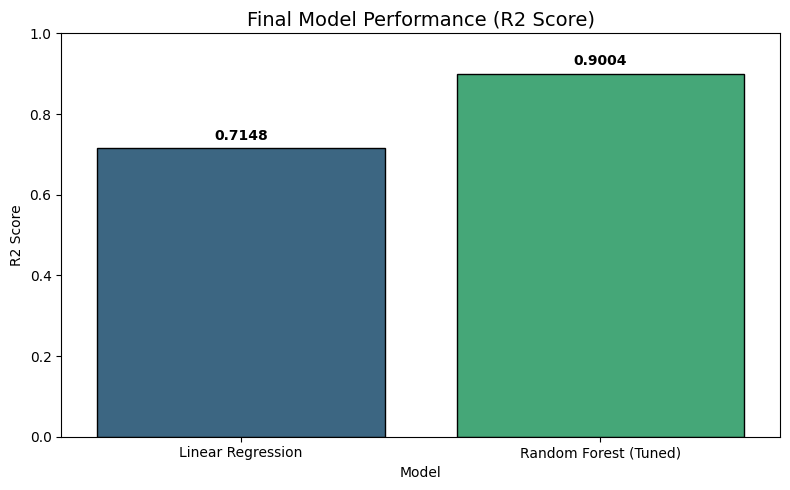

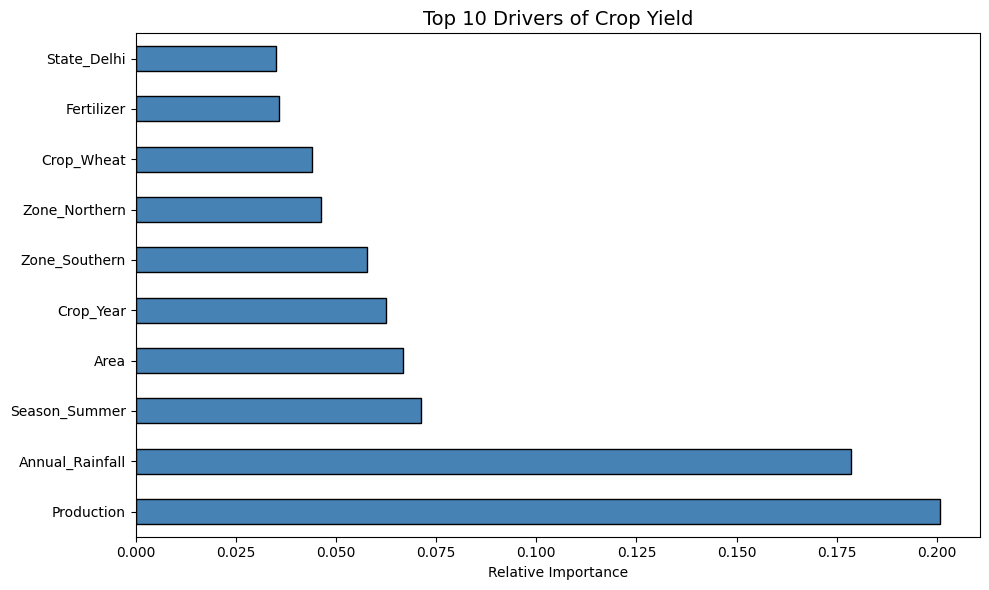

In [6]:
# Final summary visualisations for the stakeholder report
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pandas as pd

# 1. Model Performance Comparison Chart
performance_data = {
    'Model': ['Linear Regression', 'Random Forest (Tuned)'],
    'R2 Score': [0.7148, 0.9004]
}
df_perf = pd.DataFrame(performance_data)

plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='R2 Score', data=df_perf, palette='viridis', edgecolor='black')
plt.title('Final Model Performance (R2 Score)', fontsize=14)
plt.ylim(0, 1.0)
for i, v in enumerate(df_perf['R2 Score']):
    plt.text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/final_model_comparison.png')
plt.show()

# 2. Feature Importance Chart (for the deployed Random Forest)
model = joblib.load('../models/crop_yield_rf_model.joblib')
rf_model = model.named_steps['regressor']

# Get feature names from the data used in Phase 6 retraining cell
df_all = pd.read_csv('../data/processed/crop_yield_cleaned.csv')
feature_names = df_all.drop(columns=['yield_per_hectare']).columns

importances = rf_model.feature_importances_
feat_importances = pd.Series(importances, index=feature_names)

plt.figure(figsize=(10, 6))
feat_importances.nlargest(10).plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 10 Drivers of Crop Yield', fontsize=14)
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.savefig('../figures/top_features.png')
plt.show()


### Task 4: Looking back on the project

What worked well? What was a struggle? This retrospective helps us learn from the process and do better on the next data science project.


In [7]:
# Looking back at what went well and what was tough.

project_retrospective = {
    "wins": [
        "The CRISP-DM workflow kept everything organized.",
        "Splitting the code into separate 'src' files made the notebooks much cleaner.",
        "Finding the drought resilience answer was a really satisfying result."
    ],
    "challenges": [
        "The raw data had some confusing column names (Annual_Rainfall vs Rainfall) that took a bit to sort out.",
        "The Wikipedia merge was tricky because state names didn't always match perfectly at first."
    ],
    "lessons": [
        "Always double-check your data assumptions early on.",
        "Simple models are often already enough, but complex ones like Random Forest really helped us capture the weather patterns better."
    ]
}

print('=== Project Retrospective ===')
for key, items in project_retrospective.items():
    print(f'\n--- {key.upper()} ---')
    for item in items:
        print(f'  - {item}')


=== Project Retrospective ===

--- WINS ---
  - The CRISP-DM workflow kept everything organized.
  - Splitting the code into separate 'src' files made the notebooks much cleaner.
  - Finding the drought resilience answer was a really satisfying result.

--- CHALLENGES ---
  - The raw data had some confusing column names (Annual_Rainfall vs Rainfall) that took a bit to sort out.
  - The Wikipedia merge was tricky because state names didn't always match perfectly at first.

--- LESSONS ---
  - Always double-check your data assumptions early on.
  - Simple models are often already enough, but complex ones like Random Forest really helped us capture the weather patterns better.


---

## Key Takeaway on Iteration

While the six CRISP-DM phases are presented **sequentially** in these notebooks, in practice the process is **highly iterative**. Real-world data science projects rarely follow a straight line from Phase 1 to Phase 6.

Common iteration patterns include:

- **Modelling → Data Preparation:** If the model performs poorly, you may return to Phase 3 to engineer new features, clean data differently, or acquire more data.
- **Evaluation → Modelling:** If the model does not meet the business success criteria, you may go back to Phase 4 to try different algorithms or tune hyperparameters.
- **Deployment → Evaluation:** If the deployed model underperforms in production (data drift), you may return to Phase 5 to re-evaluate and then to Phase 3/4 to retrain.
- **Any Phase → Business Understanding:** New findings in later phases may redefine the business objectives or success criteria originally set in Phase 1.

```
┌───────────────────────────────────────────────────────────┐
│                     CRISP-DM Lifecycle                    │
│                                                           │
│   Phase 1 ──► Phase 2 ──► Phase 3 ──► Phase 4            │
│   Business    Data        Data        Modelling           │
│   Under.      Under.      Prep.           │               │
│     ▲                       ▲              │               │
│     │                       │              ▼               │
│     │                       └──────── Phase 5             │
│     │                                Evaluation           │
│     │                                    │                │
│     │                                    ▼                │
│     └──────────────────────────────  Phase 6              │
│                                     Deployment            │
└───────────────────────────────────────────────────────────┘
```

> **Remember:** Iteration is not failure — it is the *expected* workflow. Each cycle through the process deepens your understanding of both the data and the business problem, ultimately leading to a better solution.